<a href="https://colab.research.google.com/github/yuvalamir336/python-for-numerical-methods-classroom-db4e27-excentric-column-excentric-column/blob/main/Copy_of_numerical_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# שיעור: מציאת שורשים (Root Finding) עם SciPy
**קורס: פייתון עבור שיטות נומריות בהנדסה**

## 1. הקדמה תיאורטית
בבעיות הנדסיות רבות, עלינו למצוא ערך של משתנה $x$ עבורו מתקיים $f(x) = 0$. ערך זה נקרא **שורש** של הפונקציה.
כפי שראינו בנוסחת הסקנט לקריסת עמודים, לא תמיד ניתן לבודד את $x$ אלגברית.

נלמד שתי שיטות מרכזיות מתוך ספריית `scipy.optimize`:

### א. שיטת החצייה (Bisection Method)
שיטה יציבה מאוד (Robust) המבוססת על משפט ערך הביניים. אם פונקציה רציפה מחליפה סימן בין $a$ ל-$b$, קיים לפחות שורש אחד ביניהם.
* **יתרון:** תמיד מתכנסת אם קיים שורש.
* **חיסרון:** איטית יחסית.



### ב. שיטת ניוטון-רפסון (Newton-Raphson Method)
שיטה המשתמשת בנגזרת של הפונקציה כדי "לנחש" את המיקום הבא של השורש בעזרת משיק.
* **יתרון:** מהירה מאוד (התכנסות ריבועית).
* **חיסרון:** עלולה להתבדר אם הניחוש הראשוני רחוק מדי או אם הנגזרת מתאפסת.



---

## 2. הגדרת הפונקציה לדוגמה
נחפש את השורש של הפונקציה:
$$f(x) = x^2 - 5$$
(השורש הוא $\sqrt{5} \approx 2.236$)

```python
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize

def f(x):
    return x**2 - 5

# נשרטט את הפונקציה כדי לראות איפה השורש
x_range = np.linspace(0, 4, 100)
plt.plot(x_range, f(x_range))
plt.axhline(0, color='black', linestyle='--')
plt.title("f(x) = x^2 - 5")
plt.grid()
plt.show()
```

---



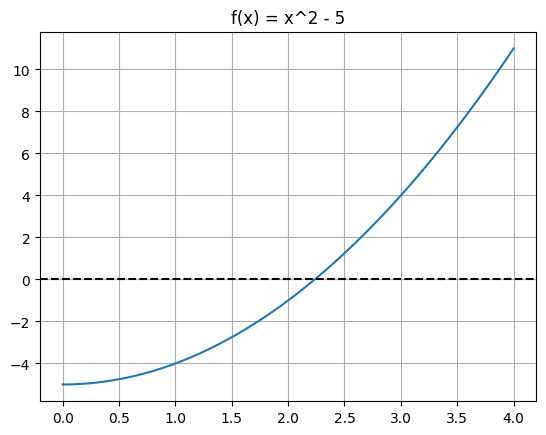

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize
def f(x):
  return x**2 - 5
# נשרטט את הפונקציה כדי לראות איפה השורש
x_range = np.linspace(0, 4, 100)
plt.plot(x_range, f(x_range))
plt.axhline(0, color='black', linestyle='--')
plt.title("f(x) = x^2 - 5")
plt.grid()
plt.show()

## 3. שימוש ב-`scipy.optimize.bisect`
כדי להשתמש בשיטת החצייה, עלינו לספק תחום $[a, b]$ שבו הפונקציה מחליפה סימן.

```python
# נגדיר את התחום שבו השורש נמצא (למשל בין 1 ל-4)
a, b = 1, 4

root_bisect = optimize.bisect(f, a, b)
print(f"השורש לפי שיטת החצייה: {root_bisect}")
```
נסו את זה (הפעם לא כתבתי לכם את הקוד)



In [12]:
a, b = 2, 2.7
root_bisect = optimize.bisect(f, a, b)
print(f"השורש לפי שיטת החצייה: {root_bisect}")

השורש לפי שיטת החצייה: 2.23606797750017



## 4. שימוש ב-`scipy.optimize.newton`
בשיטת ניוטון-רפסון, עלינו לספק "ניחוש ראשוני" ($x_0$).

```python
# ניחוש ראשוני
x0 = 3

root_newton = optimize.newton(f, x0)
print(f"השורש לפי שיטת ניוטון-רפסון: {root_newton}")
```


In [13]:

root_newton = optimize.newton(f, 2)
print(f"השורש לפי שיטת ניוטון-רפסון: {root_newton}")

השורש לפי שיטת ניוטון-רפסון: 2.2360679774997894




## 5. השוואה והנדסה: מה קורה כשאין פתרון פשוט?
נדגים את הבעיה מהמטלה שלנו (נוסחת הסקנט בגרסה פשוטה):
נתונה פונקציית מאמץ שצריכה להשתוות למאמץ מותר של $250 MPa$.




In [14]:
def column_stress_error(P, sigma_allow=250):
    L, E, A, r, c, e = 3000, 200000, 5000, 50, 100, 20
    # נוסחת הסקנט
    # Note: Ensure the argument to np.cos is not too close to pi/2 + k*pi, as it can cause `OverflowError`.
    # This is a common issue with the secant formula for columns approaching critical load.
    sec_term = 1 / np.cos((L/(2*r)) * np.sqrt(P/(E*A)))
    sigma_max = (P/A) * (1 + (e*c/r**2) * sec_term)
    return sigma_max - sigma_allow


In [15]:
# @title
from scipy import optimize

def find_critical_load(L, E, A, r, c, e, sigma_allow):
  # Create a lambda function that fixes L, E, A, r, c, e, sigma_allow
  # and only exposes P for optimize.newton
  # A good initial guess for P is crucial for newton's method.
  # Here, we provide an initial guess of 500000 N.
  P_critical = optimize.newton(lambda P: column_stress_error(P, L, E, A, r, c, e, sigma_allow), 500000)
  return P_critical


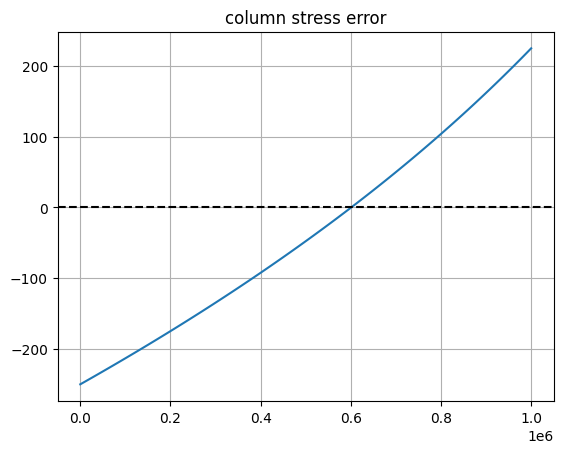

In [16]:
x = np.linspace(0, 1000000, 100)
plt.plot(x, column_stress_error(x))
plt.axhline(0, color='black', linestyle='--')
plt.title("column stress error")
plt.grid()
plt.show()

עכשיו נמצא את העומס המקסימלי. מכיוון שהפונקציה


```
optimize.bisect
```
מחפשת שורשים, הגדרנו מראש את המרחק מהעומס המותר בתוך הפונקציה


In [17]:
# מציאת העומס P המקסימלי בעזרת Bisection
# נחפש בין עומס 0 לעומס גבוה מאוד (1,000,000 ניוטון)
P_max = optimize.bisect(column_stress_error, 500000, 700000)
print(f"העומס המקסימלי המותר הוא: {P_max:.2f} N")

העומס המקסימלי המותר הוא: 601247.99 N


In [18]:
P_max = optimize.newton(column_stress_error, 500000)
print(f"maximum aloud load {P_max:.2f} N")

maximum aloud load 601247.99 N



---

## 6. תרגיל עצמי לסטודנטים
1. שנו את ערך האקסצנטריות ($e$) בתוך פונקציית העזר. איך זה משפיע על העומס המקסימלי $P$?
2. נסו להשתמש בשיטת `newton` עבור פונקציית העמוד. האם היא תמיד מתכנסת? (רמז: נסו ניחוש ראשוני שקרוב מאוד לערך הקריטי שבו הקוסינוס מתאפס).




# מטלה 3: פתרון נומרי לבעיית קריסה של עמוד (Secant Formula)

### הקדמה הנדסית
בתכנון מבני פלדה, חישוב עומס קריסה של עמוד אידיאלי מתבצע לפי נוסחת אוילר. עם זאת, במציאות, העומס כמעט תמיד פועל באקסצנטריות ($e$) ביחס לציר הנייטרלי של החתך. במצב זה, העמוד מתפקד כ-"קורה-עמוד" (Beam-Column), והמאמץ המקסימלי בו מתקבל לפי **נוסחת הסקנט**.

הבעיה היא שנוסחת הסקנט היא משוואה טרנסצנדנטית (לא-ליניארית), ולא ניתן לבודד ממנה את העומס המקסימלי המותר ($P$) באופן אנליטי. במטלה זו נשתמש בשיטות נומריות כדי למצוא את העומס הזה.

### הנוסחה
המאמץ המקסימלי בסיב הקיצוני של העמוד נתון ע"י:
$$\sigma_{max} = \frac{P}{A} \left[ 1 + \frac{ec}{r^2} \sec \left( \frac{L}{2r} \sqrt{\frac{P}{EA}} \right) \right]$$

כאשר:
* $P$ - העומס הצירי הפועל על העמוד ($N$).
* $A$ - שטח חתך העמוד ($mm^2$).
* $e$ - אקסצנטריות העומס ($mm$).
* $c$ - המרחק מהציר הנייטרלי לסיב הקיצוני ($mm$).
* $r$ - רדיוס האינרציה של החתך ($mm$).
* $L$ - אורך העמוד ($mm$).
* $E$ - מודול האלסטיות ($MPa$).

---

### המשימה
עליכם לכתוב פונקציה בשם `find_critical_load` המקבלת את נתוני העמוד ומוצאת את העומס המקסימלי $P$ שיביא את העמוד למאמץ המקסימלי המותר ($\sigma_{allowable}$).

#### דרישות המימוש:
1.  **קובץ הפתרון:** עליכם לעבוד בקובץ `column_buckling.py`.
2.  **מבנה הפונקציה:**
    ```python
    def find_critical_load(L, E, A, r, c, e, sigma_allow):
        """
        L: אורך במ"מ
        E: מודול אלסטיות ב-MPa
        A: שטח חתך בממ"ר
        r: רדיוס אינרציה במ"מ
        c: מרחק לסיב קיצוני במ"מ
        e: אקסצנטריות במ"מ
        sigma_allow: מאמץ מותר ב-MPa
        
        Return: העומס P בניוטון (float)
        """
        # כתבו כאן את הקוד
    ```
3.  **שיטה נומרית:** ניתן להשתמש בשיטת החצייה (Bisection) או בשיטת ניוטון-רפסון. מומלץ להשתמש ב-`scipy.optimize.bisect` או `scipy.optimize.newton`.

---

### הנחיות לעבודה עם NumPy ו-SciPy
* זכרו כי פונקציית ה-`secant` אינה קיימת ישירות ב-`numpy`. השתמשו ב: `1 / np.cos(...)`.
* שימו לב שהארגומנט בתוך ה-`cos` הוא ברדיאנים.
* כדי למצוא את $P$, עליכם להגדיר פונקציית עזר $f(P) = \sigma_{max}(P) - \sigma_{allow}$ ולמצוא את השורש שלה.

### בדיקת הפתרון (Unit Testing)
המטלה כוללת קובץ בדיקות אוטומטיות `test_buckling.py`. המערכת תבדוק את הקוד שלכם עבור מספר חתכים (HEB, IPE) ותוודא שהעומס שמצאתם אכן מקיים את המשוואה בדיוק של $10^{-3}$.

כדי להריץ את הבדיקות מקומית:
```bash
pytest test_buckling.py
```

---

### הגשה
יש לבצע `commit` ו-`push` לקובץ `column_buckling.py` בלבד. ודאו שה-Action בגיטהאב הופך לירוק.

**בהצלחה!**
.